<a href="https://colab.research.google.com/github/overdrivethinker/UT-STDA4204-Machine-Learning/blob/main/Tugas3b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Customer Personality Analysis - Unsupervised Learning Tugas 3


import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load dataset

In [2]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/cpa.csv',  sep='\t')

print(df.shape)
print(df.head())
print(df.info())

Mounted at /content/drive
(2240, 29)
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  04-09-2012       58       635  ...                  7             0   
1  08-03-2014       38        11  ...                  5             0   
2  21-08-2013       26       426  ...                  4             0   
3  10-02-2014       26        11  ...                  6             0   
4  19-01-2014       94       173  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  Acce

#Step2: lakukan Eksplorasi awal

ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object
                 ID   Year_Birth         Income      Kidhome     Teenhome  \
count   22

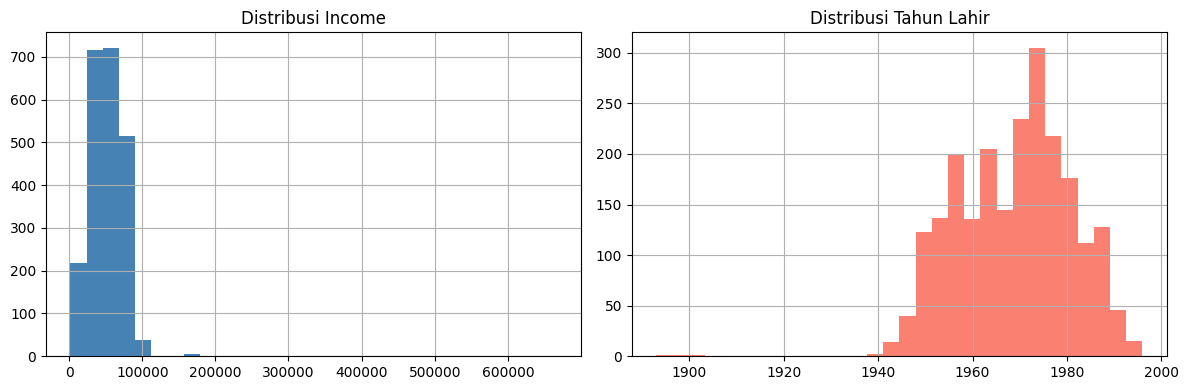

In [3]:
print(df.dtypes)
print(df.describe())
print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['Income'].hist(ax=axes[0], bins=30, color='steelblue')
axes[0].set_title('Distribusi Income')
df['Year_Birth'].hist(ax=axes[1], bins=30, color='salmon')
axes[1].set_title('Distribusi Tahun Lahir')
plt.tight_layout()
plt.show()

# Step 3: Identifikasi kolom numerik & kategori

In [4]:
drop_cols = ['ID', 'Z_CostContact', 'Z_Revenue', 'Dt_Customer']
df_clean = df.drop(columns=drop_cols)

cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
num_cols = df_clean.select_dtypes(include='number').columns.tolist()
print("Kategori:", cat_cols)
print("Numerik:", num_cols)

Kategori: ['Education', 'Marital_Status']
Numerik: ['Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response']


# Step 4: Imputasi missing value

In [5]:
imputer_num = SimpleImputer(strategy='median')
df_clean[num_cols] = imputer_num.fit_transform(df_clean[num_cols])

imputer_cat = SimpleImputer(strategy='most_frequent')
df_clean[cat_cols] = imputer_cat.fit_transform(df_clean[cat_cols])

print("Missing setelah imputasi:")
print(df_clean.isnull().sum().sum())

Missing setelah imputasi:
0



# Step 5: Encoding fitur kategori

In [6]:
encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded_arr = encoder.fit_transform(df_clean[cat_cols])
encoded_cols = encoder.get_feature_names_out(cat_cols)
df_encoded = pd.DataFrame(encoded_arr, columns=encoded_cols, index=df_clean.index)


#Gabungkan data numerik & hasil encoding

In [7]:
df_combined = pd.concat([df_clean[num_cols], df_encoded], axis=1)
print(f"Shape setelah encoding: {df_combined.shape}")

Shape setelah encoding: (2240, 34)


# Step 6: Scaling data

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_combined)
print(f"Shape data siap clustering: {X_scaled.shape}")
print(f"Mean: {X_scaled.mean(axis=0)[:3].round(4)}")
print(f"Std : {X_scaled.std(axis=0)[:3].round(4)}")

Shape data siap clustering: (2240, 34)
Mean: [-0. -0. -0.]
Std : [1. 1. 1.]



# Step 7: Tentukan jumlah cluster optimal (Elbow + Silhouette)

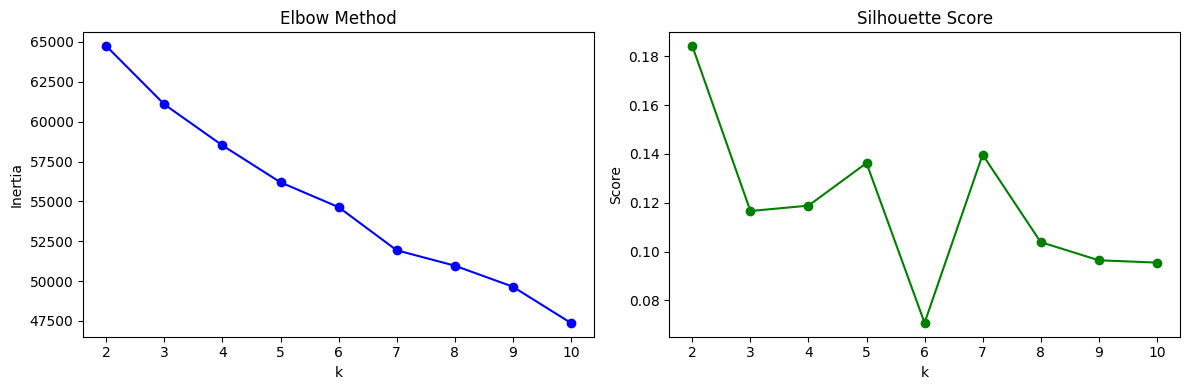

In [9]:
inertias, sil_scores = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, sil_scores, 'go-')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Score')
plt.tight_layout(); plt.show()

# Step 8: Pilih k optimal dan klasterisasi

In [10]:
k_optimal = 4  # Ganti sesuai hasil Step 7

kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df_combined['Cluster'] = kmeans.fit_predict(X_scaled)

print("Distribusi klaster:")
print(df_combined['Cluster'].value_counts().sort_index())
print(f"\nSilhouette Score: {silhouette_score(X_scaled, df_combined['Cluster']):.4f}")

Distribusi klaster:
Cluster
0    1002
1     454
2     613
3     171
Name: count, dtype: int64

Silhouette Score: 0.1188


# Step 9: Visualisasi klaster dengan PCA 2D

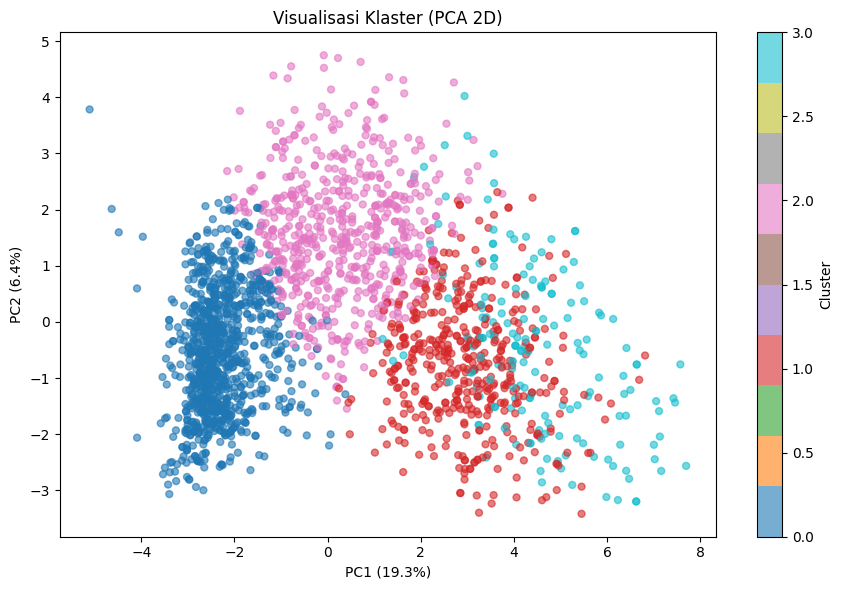

Explained variance: 25.7%


In [11]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=df_combined['Cluster'],
                      cmap='tab10', alpha=0.6, s=25)
plt.colorbar(scatter, label='Cluster')
plt.title('Visualisasi Klaster (PCA 2D)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.tight_layout(); plt.show()

print(f"Explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%")

# Step 10: Profiling cluster (rata-rata fitur per cluster)

Cluster                  0        1        2        3
Income             34413.1  74027.4  57054.3  81569.5
MntWines              37.6    491.0    441.4    874.7
MntMeatProducts       22.3    428.5    125.4    469.1
MntFruits              4.8     71.6     19.4     56.4
NumWebPurchases        2.1      5.2      6.2      5.4
NumStorePurchases      3.1      8.4      7.5      8.3
Recency               49.2     49.4     48.5     49.8
Kidhome                0.8      0.1      0.2      0.1


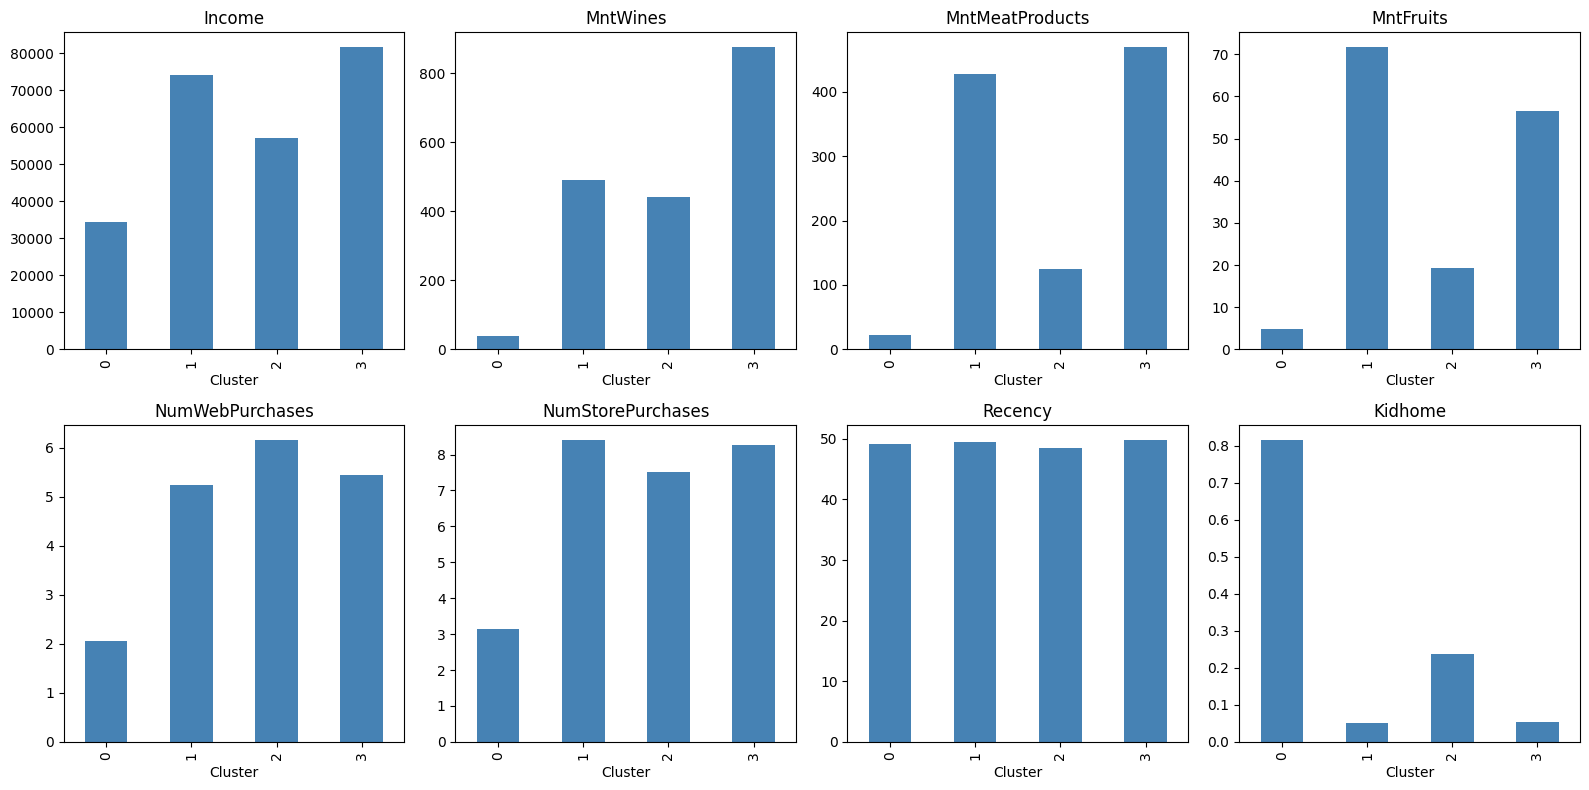

In [12]:
key_features = ['Income', 'MntWines', 'MntMeatProducts',
                 'MntFruits', 'NumWebPurchases',
                 'NumStorePurchases', 'Recency', 'Kidhome']

profile = df_combined.groupby('Cluster')[key_features].mean().round(1)
print(profile.T)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, feat in enumerate(key_features):
    ax = axes[i//4][i%4]
    df_combined.groupby('Cluster')[feat].mean().plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(feat); ax.set_xlabel('Cluster')
plt.tight_layout(); plt.show()

# Simpulkan Analisa dari hasil

Berdasarkan hasil clustering K-Means dengan k=4, ditemukan 4 segmen pelanggan yang berbeda karakteristiknya.

**Cluster 0 — Budget Conscious** adalah kelompok pelanggan dengan income terendah (~35K), memiliki banyak anak, dan pengeluaran paling rendah di semua kategori produk. Mereka jarang belanja online maupun di toko.

**Cluster 1 — High-Value Omnivore** memiliki income tinggi (~74K) dengan konsumsi daging dan buah tertinggi. Mereka aktif berbelanja di semua channel dan hampir tidak memiliki anak di rumah.

**Cluster 2 — Digital Middle-Class** adalah segmen menengah (~58K) yang paling aktif berbelanja online dibanding cluster lainnya, meski pengeluaran totalnya tidak setinggi Cluster 1 dan 3.

**Cluster 3 — Elite Wine Connoisseur** merupakan segmen dengan income tertinggi (~82K) dan pengeluaran terbesar, terutama untuk wine (~850) dan daging (~490). Segmen ini hampir tidak memiliki anak dan menjadi kontributor revenue terbesar.

Secara keseluruhan, income dan jumlah anak di rumah terbukti menjadi faktor pembeda utama antar segmen. Semakin tinggi income dan semakin sedikit tanggungan anak, semakin besar pengeluaran pelanggan. Recency yang merata di semua cluster menunjukkan bahwa frekuensi kunjungan bukan pembeda segmen — yang membedakan adalah nilai transaksinya. Perusahaan disarankan fokus mempertahankan Cluster 3 dan 1 sebagai sumber revenue utama, mengoptimalkan channel digital untuk Cluster 2, serta merancang program promosi hemat untuk mendorong Cluster 0 agar meningkat ke segmen yang lebih tinggi.